In [68]:
import pickle
import torch
import matplotlib.pyplot as plt
import pandas as pd

from src.data.dataloader import TimeSeriesDataset

# Path to your model pickle
model_path = "results/windPrc-cfrnn-42.pkl"

# Load the model
with open(model_path, "rb") as f:
    results = pickle.load(f)



## error on valdation set over the last 4 days of the training series data

In [69]:
rmse = torch.sqrt((results['Errors']**2).mean()).item()
rmse

2.5806167125701904

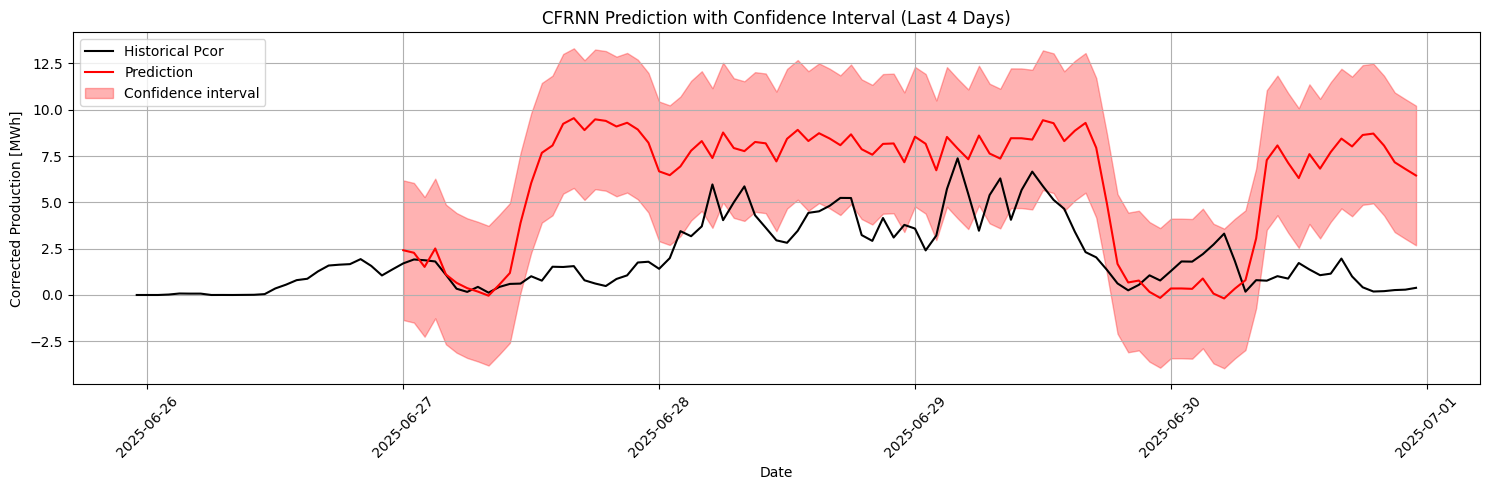

In [72]:
# Load historical data
df = pd.read_csv('data/historical_data.csv', sep=';')
df = df.dropna(subset=['DateTime CET'])
df['date'] = pd.to_datetime(df['DateTime CET'], format='%d/%m/%Y %H:%M', errors='coerce')

# Convert percentages
df['Availability'] = df['Availability'].str.replace('%','', regex=False).astype(float) / 100
df['ODD'] = df['ODD'].str.replace('%','', regex=False).astype(float) / 100

# Filter invalid rows
df = df[(df['ODD'] >= 0.01) & (df['Availability'] > 0)]

# Convert production to numeric
df['Production [MWh]'] = df['Production [MWh]'].str.replace(',', '.', regex=False)
df['Production [MWh]'] = pd.to_numeric(df['Production [MWh]'], errors='coerce')

# Compute corrected production
df['Pcor'] = df['Production [MWh]'] / df['Availability']

# Select last 5 days for plotting
end_date = df['date'].max()
start_date = end_date - pd.Timedelta(days=5)
mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_plot = df.loc[mask].reset_index(drop=True)

# Last 4 days for predictions
start_pred = end_date - pd.Timedelta(days=4)
mask_pred = (df['date'] >= start_pred) & (df['date'] <= end_date)
df_pred = df.loc[mask_pred].reset_index(drop=True)

# Extract predictions and intervals for the last 4 days
predictions = results['Point predictions'].detach().numpy().flatten()[-len(df_pred):]
upper = results['Upper limit'].detach().numpy().flatten()[-len(df_pred):]
lower = results['Lower limit'].detach().numpy().flatten()[-len(df_pred):]

# Number of points available for prediction
n_pred = min(len(df_pred), len(results['Point predictions'].detach().numpy().flatten()))
predictions = results['Point predictions'].detach().numpy().flatten()[-n_pred:]
upper = results['Upper limit'].detach().numpy().flatten()[-n_pred:]
lower = results['Lower limit'].detach().numpy().flatten()[-n_pred:]

# Align dates for plotting
dates_pred = df_pred['date'].iloc[-n_pred:]

# Plot
plt.figure(figsize=(15,5))

# Historical 5 days
plt.plot(df_plot['date'], df_plot['Pcor'], label='Historical Pcor', color='black')

# Predictions for last 4 days
plt.plot(dates_pred, predictions, label='Prediction', color='red')
plt.fill_between(dates_pred, lower, upper, color='red', alpha=0.3, label='Confidence interval')

plt.xlabel('Date')
plt.ylabel('Corrected Production [MWh]')
plt.title('CFRNN Prediction with Confidence Interval (Last 4 Days)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_prediction_from_csv(path, sample_id=0):
    df = pd.read_csv(path)

    # Filter one sample
    df_sample = df.sort_values("horizon_step")

    x = df_sample["sample"].values
    preds = df_sample["prediction"].values
    lower = df_sample["lower"].values
    upper = df_sample["upper"].values

    plt.figure(figsize=(18, 6))

    plt.plot(x, preds, label="Prediction")
    plt.fill_between(x, lower, upper, alpha=0.3, label="Confidence interval")

    plt.xlabel("time step")
    plt.ylabel("Pcor")
    plt.title(f"CFRNN Forecast")
    plt.legend()

    plt.show()

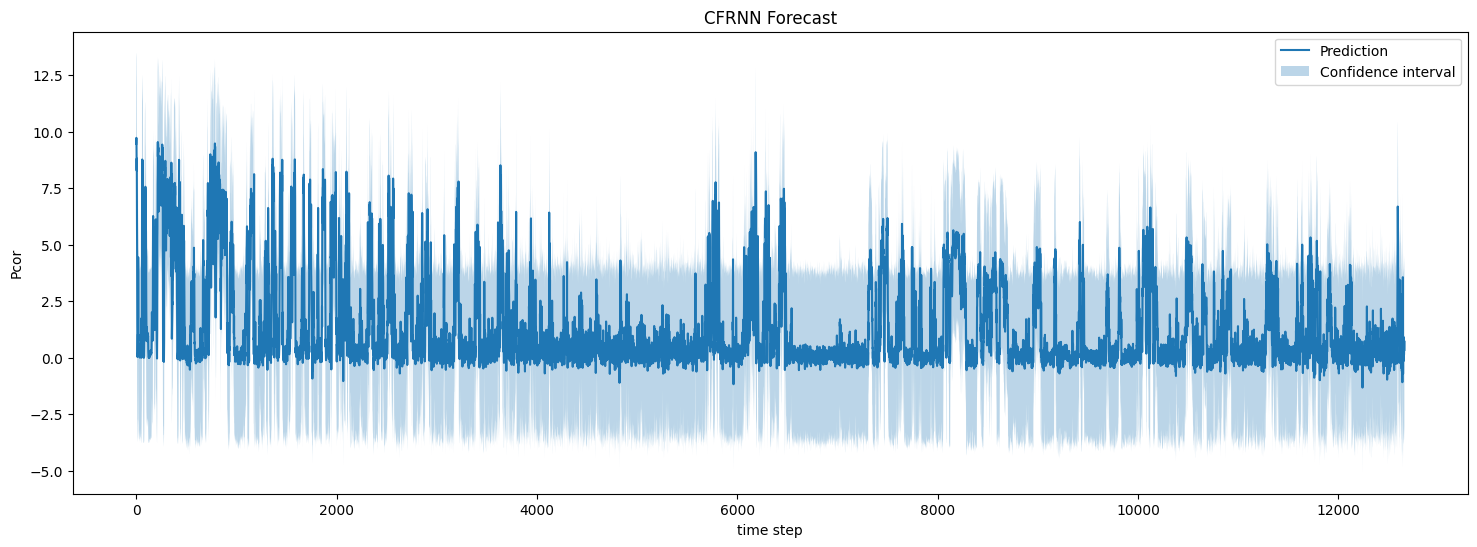

In [74]:
plot_prediction_from_csv('results/predictions.csv')